# Model Training and Evaluation

Train regression models on the processed maize-yield features, compare validation performance, and evaluate the best model on the held-out test set.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# Support running from either the project root or the notebooks folder.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

DATA_DIR

WindowsPath('c:/Users/rt/Desktop/maize-yield-project/data/processed')

In [2]:
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_val = pd.read_csv(DATA_DIR / "y_val.csv").squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
X_train.head()

Train: (116776, 18), Validation: (25024, 18), Test: (25024, 18)


,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Region_East,Region_North,Region_South,Region_West,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny
0,820.123233,16.968630,1,1,90,False,False,False,True,False,True,False,False,False,False,False,False,True
1,573.334747,22.100058,0,1,101,False,True,False,False,False,False,False,False,False,True,True,False,False
2,187.178389,35.264076,0,0,70,False,True,False,False,False,False,True,False,False,False,False,True,False
3,204.920000,34.214179,1,1,89,True,False,False,False,False,False,False,False,True,False,True,False,False
4,587.431861,24.921144,1,1,130,False,False,False,True,False,False,True,False,False,False,True,False,False


In [3]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


models = {
    "linear_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "random_forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "gradient_boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

try:
    from xgboost import XGBRegressor

    models["xgboost"] = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
except ImportError:
    print("xgboost is not installed; skipping XGBRegressor.")

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    metrics = regression_metrics(y_val, model.predict(X_val))
    results.append({"model": name, **metrics})

validation_results = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
validation_results

,model,MAE,RMSE,R2
0,linear_regression,0.399851,0.500628,0.913804
1,xgboost,0.401599,0.502374,0.913202
2,gradient_boosting,0.401485,0.502539,0.913145
3,random_forest,0.415224,0.519632,0.907136


In [4]:
best_name = validation_results.loc[0, "model"]
best_model = fitted_models[best_name]

test_metrics = regression_metrics(y_test, best_model.predict(X_test))
print(f"Best validation model: {best_name}")
pd.DataFrame([test_metrics], index=[best_name])

Best validation model: linear_regression


,MAE,RMSE,R2
linear_regression,0.399984,0.501229,0.912845


In [6]:
# Sanity check: test set size and a hash-based fingerprint, so we can confirm
# this exact test set was never part of training or model-selection decisions
import hashlib

def df_fingerprint(df):
    return hashlib.md5(pd.util.hash_pandas_object(df, index=True).values).hexdigest()

print(f"Train size: {len(X_train)}")
print(f"Val size:   {len(X_val)}")
print(f"Test size:  {len(X_test)}")
print(f"\nTest set fingerprint: {df_fingerprint(X_test)}")
print("(Compare this against the fingerprint from data loading/preprocessing —")
print(" if it matches, this is genuinely the same untouched test set throughout)")

# Explicit reminder check: model selection should have only used
# train (.fit) and val (.score / metrics for comparison) — test should
# appear ONLY in this final evaluation step, exactly once

Train size: 116776
Val size:   25024
Test size:  25024

Test set fingerprint: 5cd9182dc724628a469b4e407e082146
(Compare this against the fingerprint from data loading/preprocessing —
 if it matches, this is genuinely the same untouched test set throughout)


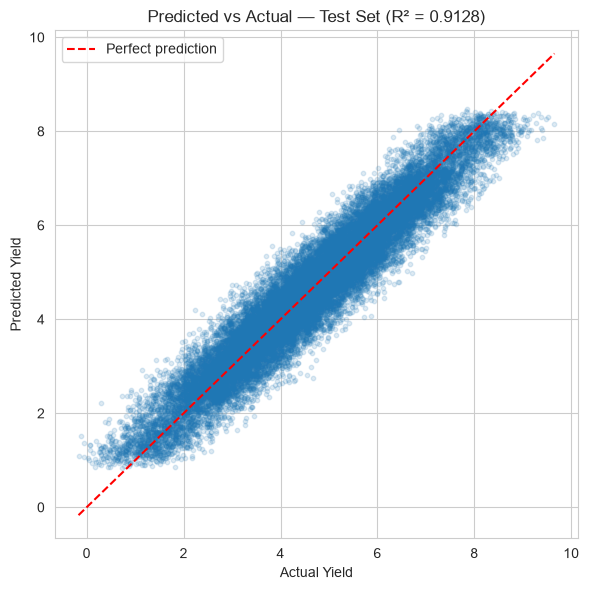

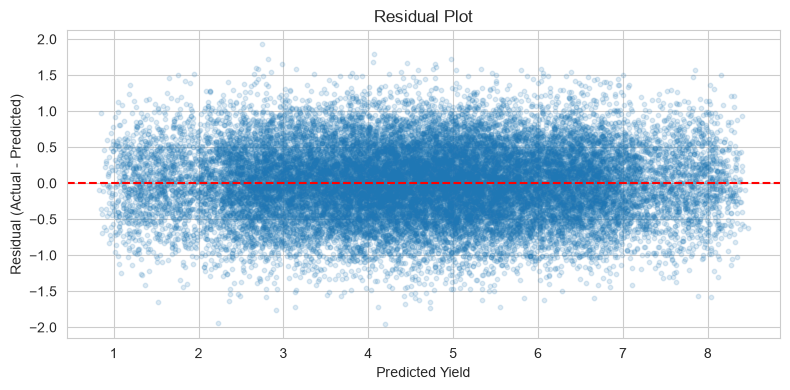

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Replace `best_model` with whatever variable holds your final chosen model
y_pred_test = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.15, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect prediction")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title(f"Predicted vs Actual — Test Set (R² = {r2_score(y_test, y_pred_test):.4f})")
plt.legend()
plt.tight_layout()
plt.show()

# Residual plot — flat, random scatter around 0 = good linear fit;
# a curved/funnel pattern would indicate the model is missing something
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_test, residuals, alpha=0.15, s=10)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Yield")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

In [14]:
# If your best/final model is linear regression:
if hasattr(best_model, "coef_"):
    coefs = pd.Series(best_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
    print("Linear Regression Coefficients (sorted by magnitude):")
    print(coefs)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=coefs.values, y=coefs.index, color="steelblue")
    plt.title("Linear Regression Coefficients")
    plt.xlabel("Coefficient value")
    plt.tight_layout()
    plt.show()

# If your best/final model is tree-based (XGBoost/RandomForest/GradientBoosting):
elif hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print("Feature Importances:")
    print(importances)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, color="steelblue")
    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
# Inspect the pipeline's steps to find the actual fitted estimator
print(best_model.named_steps)


{'scaler': StandardScaler(), 'model': LinearRegression()}


Linear Regression Coefficients (sorted by magnitude):
Rainfall_mm                 1.296706
Fertilizer_Used             0.747926
Irrigation_Used             0.601288
Temperature_Celsius         0.144606
Soil_Type_Silt             -0.002507
Soil_Type_Chalky            0.002488
Soil_Type_Peaty            -0.002157
Soil_Type_Clay              0.002047
Soil_Type_Sandy             0.001088
Region_North                0.000990
Soil_Type_Loam             -0.000957
Region_South               -0.000861
Region_West                -0.000806
Weather_Condition_Sunny     0.000722
Region_East                 0.000678
Weather_Condition_Rainy    -0.000636
Days_to_Harvest             0.000328
Weather_Condition_Cloudy   -0.000088
dtype: float64


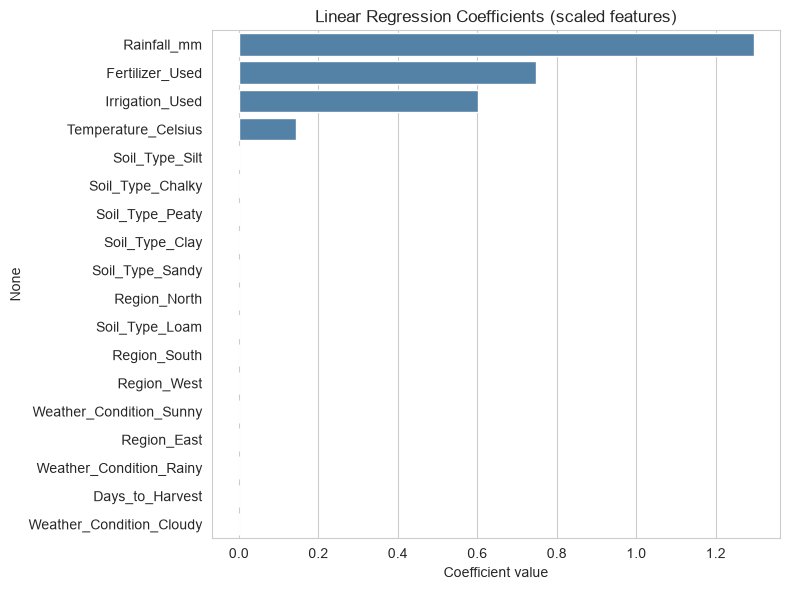

In [16]:
final_estimator = best_model.named_steps['model']

coefs = pd.Series(final_estimator.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print("Linear Regression Coefficients (sorted by magnitude):")
print(coefs)

plt.figure(figsize=(8, 6))
sns.barplot(x=coefs.values, y=coefs.index, color="steelblue")
plt.title("Linear Regression Coefficients (scaled features)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

In [15]:
print(best_model.named_steps)


{'scaler': StandardScaler(), 'model': LinearRegression()}


In [17]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/linear_regression_pipeline.pkl")
print("Saved tabular model to models/linear_regression_pipeline.pkl")

Saved tabular model to models/linear_regression_pipeline.pkl
